In [3]:
import numpy as np
import matplotlib.pyplot as plt

loads = [1]
data = {}
Policies = ["SRF", "FCFS"]
for Policy in Policies:
    data[Policy] = {}
    for load in loads:
        data[Policy][load] = np.loadtxt("../../DATA/{Policy}/Treshold=100000/single-srcs-dsts/DATA_W5_{load}/match_ratio.txt".format(Policy=Policy, load=load))

SRF 1 mean allocated slot: 25.663607518328952
SRF 1 mean allocated path: 23.228761758196153
FCFS 1 mean allocated slot: 25.9816252393479
FCFS 1 mean allocated path: 24.06725004921172


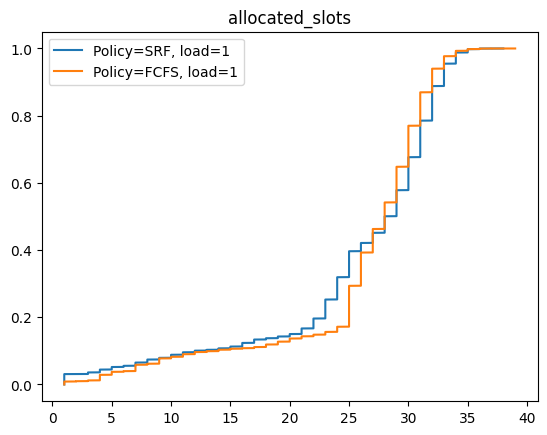

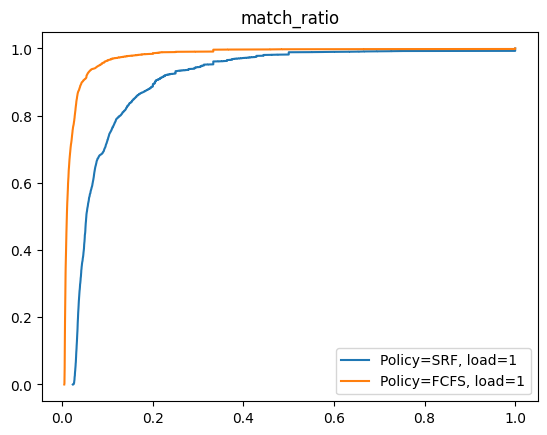

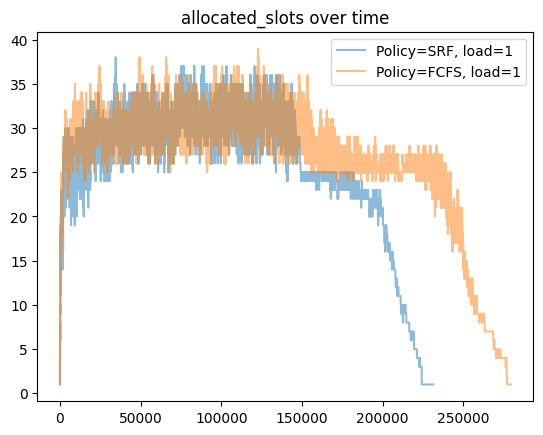

In [4]:
fig1,ax1 = plt.subplots()
fig2,ax2 = plt.subplots()
fig3,ax3 = plt.subplots()
for Policy in Policies:
    for load in loads:
        # 筛选掉第一列为0的行
        data[Policy][load] = data[Policy][load][data[Policy][load][:, 0] != 0]
        #单独绘制一张图
        # plt.title("Policy=" + Policy + ", load=" + str(load))
        # plt.xlabel("time")
        # plt.plot(x, data[Policy][load][:, 0], label='total demand')
        # plt.plot(x, data[Policy][load][:, 1]+ data[Policy][load][:, 2], label='slot-allocated')
        # # print("allocated_src_dst_pair: ", np.mean(data[Policy][load][:, 1]+ data[Policy][load][:, 2]))
        # # print("allocated aggs: ", np.mean(data[Policy][load][:, 1]))
        x = np.arange(0, len(data[Policy][load]))
        ax3.plot(x, data[Policy][load][:, 1] + data[Policy][load][:, 2], label='Policy=' + Policy + ', load=' + str(load), alpha=0.5)
        ax3.title.set_text("allocated_slots over time")
        ax3.legend()
        
        allocated_slots = data[Policy][load][:, 1] + data[Policy][load][:, 2]
        # 绘制allocated_slots的CDF
        allocated_slots = np.sort(allocated_slots)
        y = np.arange(0, len(allocated_slots)) / len(allocated_slots)
        ax1.plot(allocated_slots, y, label='Policy=' + Policy + ', load=' + str(load))
        ax1.title.set_text("allocated_slots")
        print(Policy, load, "mean allocated slot:", np.mean(allocated_slots))
        print(Policy, load, "mean allocated path:", np.mean(data[Policy][load][:, 1]))

        
        match_ratio = (data[Policy][load][:, 1] + data[Policy][load][:, 2]) /data[Policy][load][:, 0]
        # 绘制match_ratio的CDF
        match_ratio = np.sort(match_ratio)
        y = np.arange(0, len(match_ratio)) / len(match_ratio)
        ax2.plot(match_ratio, y, label='Policy=' + Policy + ', load=' + str(load))
        ax2.title.set_text("match_ratio")
        
        
        #只看前10000个数据
        # plt.xlim(0, 10000)
        # plt.ylim(0, 200)
        ax1.legend()
        ax2.legend()